In [1]:
pip install xgboost pandas scikit-learn matplotlib seaborn

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   - -------------------------------------- 1.3/48.9 MB 8.5 MB/s eta 0:00:06
   --- ------------------------------------ 4.5/48.9 MB 12.5 MB/s eta 0:00:04
   ------- -------------------------------- 8.7/48.9 MB 15.3 MB/s eta 0:00:03
   ----------- ---------------------------- 14.2/48.9 MB 18.2 MB/s eta 0:00:02
   ---------------- ----------------------- 19.7/48.9 MB 19.6 MB/s eta 0:00:02
   ------------------ --------------------- 22.8/48.9 MB 18.6 MB/s eta 0:00:02
   --------------------- ------------------ 26.2/48.9 MB 18.4 MB/s eta 0:00:02
   ----------------------- ---------------- 29.1/48.9 MB 17.5 MB/s eta 0:00:02
   ---------------------------- ----------- 34.3/48.9 MB 18.0 MB/s eta 0:00:01
   -------------------------------- ------- 40.1/48.9 MB 18.8 MB/s eta 0:00:01
   ------------------------------------- -- 45.9/48.9 MB 19.4 MB/s eta 0:00:01
   ---------------------------------------  48.5/48.9 MB 18.7 MB/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
file = "../Dataset/final_sdb_dataset_clean.csv"
df = pd.read_csv(file)
df_shallow = df[(df['depth'] >= 0) & (df['depth'] <= 30)].copy()

In [3]:
print(f"Original rows: {len(df)} | Rows after filtering (depth <= 30): {len(df_shallow)}")

Original rows: 11676 | Rows after filtering (depth <= 30): 4548


In [5]:
df_arabian_sea = df_shallow[(df_shallow['longitude'] > 48) & (df_shallow['longitude'] < 60)].copy()
df_strait_of_hormuz = df_shallow[(df_shallow['longitude'] > 65) & (df_shallow['longitude'] < 70)].copy()
df_bay_of_bengal = df_shallow[df_shallow['longitude'] >= 70].copy()

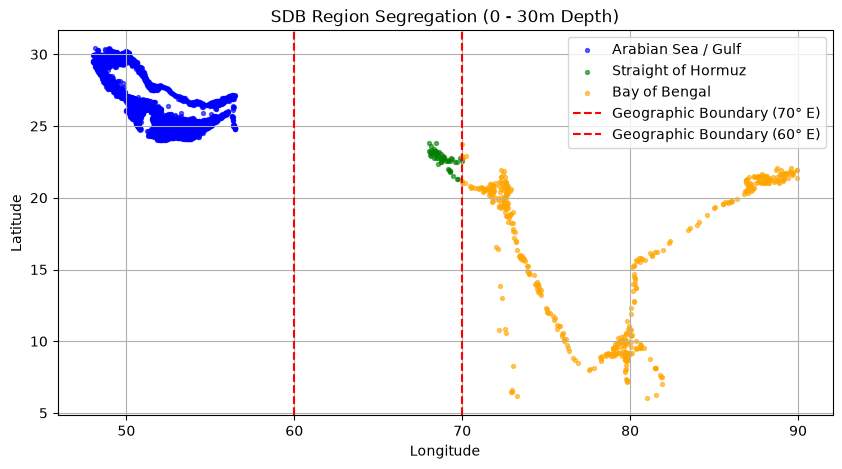

In [6]:
plt.figure(figsize=(10, 5))
plt.scatter(df_arabian_sea['longitude'], df_arabian_sea['latitude'], c='blue', label='Arabian Sea / Gulf', s=8, alpha=0.6)
plt.scatter(df_strait_of_hormuz['longitude'], df_strait_of_hormuz['latitude'], c='green', label='Straight of Hormuz', s=8, alpha=0.6)
plt.scatter(df_bay_of_bengal['longitude'], df_bay_of_bengal['latitude'], c='orange', label='Bay of Bengal', s=8, alpha=0.6)
plt.axvline(x=70, color='red', linestyle='--', label='Geographic Boundary (70° E)')
plt.axvline(x=60, color='red', linestyle='--', label='Geographic Boundary (60° E)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('SDB Region Segregation (0 - 30m Depth)')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
features = ['blue_band', 
            'green_band', 
            'log_blue', 
            'log_green', 
            'bg_ratio', 
            'stumpf_ratio']

In [9]:
X_all = df_shallow[features]
y_all = df_shallow['depth']

X_tr_all, X_te_all, y_tr_all, y_te_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

In [10]:
xgb_global = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_global.fit(X_tr_all, y_tr_all)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [11]:
y_pred_all = xgb_global.predict(X_te_all)

In [12]:
mae_all = mean_absolute_error(y_te_all, y_pred_all)
rmse_all = root_mean_squared_error(y_te_all, y_pred_all)
r2_all = r2_score(y_te_all, y_pred_all)

print("=" * 45)
print("  XGBOOST GLOBAL MODEL: ALL REGIONS")
print("=" * 45)
print(f"MAE  : {mae_all:.4f} m")
print(f"RMSE : {rmse_all:.4f} m")
print(f"R²   : {r2_all:.4f}\n")

  XGBOOST GLOBAL MODEL: ALL REGIONS
MAE  : 4.9535 m
RMSE : 6.4577 m
R²   : 0.4706



  XGBOOST SEPARATE REGIONAL MODELS
=== Arabian Sea / Gulf (N=4067) ===
  MAE  : 4.7388 m
  RMSE : 6.3162 m
  R²   : 0.4750

=== Strait of Hormuz (N=54) ===
  MAE  : 3.2836 m
  RMSE : 4.1254 m
  R²   : 0.5613

=== Bay of Bengal (N=427) ===
  MAE  : 6.6185 m
  RMSE : 8.5530 m
  R²   : 0.0060



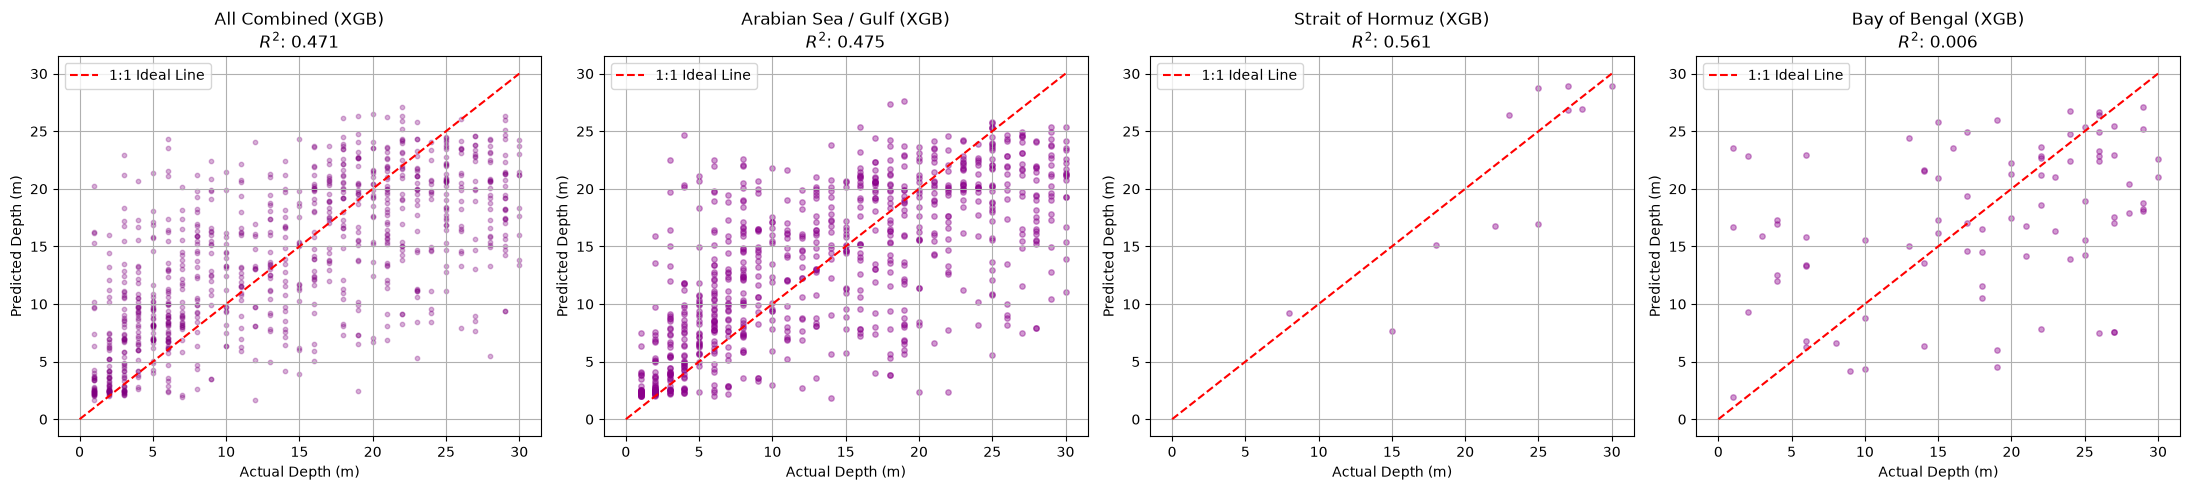

In [13]:
regions = [
    ('Arabian Sea / Gulf', df_arabian_sea),
    ('Strait of Hormuz', df_strait_of_hormuz),
    ('Bay of Bengal', df_bay_of_bengal)
]

xgb_models = {}

print("=" * 45)
print("  XGBOOST SEPARATE REGIONAL MODELS")
print("=" * 45)

# Setup subplots: 1 row with 4 plots (Combined + 3 Regions)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot Combined Results in First Subplot
axes[0].scatter(y_te_all, y_pred_all, alpha=0.3, s=10, color='purple')
axes[0].plot([0, 30], [0, 30], 'r--', label='1:1 Ideal Line')
axes[0].set_xlabel('Actual Depth (m)')
axes[0].set_ylabel('Predicted Depth (m)')
axes[0].set_title(f'All Combined (XGB)\n$R^2$: {r2_all:.3f}')
axes[0].grid(True)
axes[0].legend()

# Iterate through individual regions
for idx, (name, region_df) in enumerate(regions, start=1):
    if len(region_df) == 0:
        print(f"Skipping {name}: No samples available.")
        continue
        
    X_reg = region_df[features]
    y_reg = region_df['depth']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_reg, y_reg, test_size=0.2, random_state=42
    )
    
    # Fit individual XGBoost model
    xgb = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(X_train, y_train)
    xgb_models[name] = xgb
    
    # Predict & Evaluate
    y_pred = xgb.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"=== {name} (N={len(region_df)}) ===")
    print(f"  MAE  : {mae:.4f} m")
    print(f"  RMSE : {rmse:.4f} m")
    print(f"  R²   : {r2:.4f}\n")
    
    # Plot Region Results
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color='darkmagenta')
    ax.plot([0, 30], [0, 30], 'r--', label='1:1 Ideal Line')
    ax.set_xlabel('Actual Depth (m)')
    ax.set_ylabel('Predicted Depth (m)')
    ax.set_title(f'{name} (XGB)\n$R^2$: {r2:.3f}')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()